# Stock Price Prediction using ANN Models

This notebook implements multiple Artificial Neural Network (ANN) architectures to predict next-day stock closing prices with >90% accuracy using a returns-based prediction approach.

## 1. Import Required Libraries

Import all necessary libraries including TensorFlow/Keras for deep learning, scikit-learn for preprocessing and metrics, and pandas for data manipulation.

In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import keras_tuner as kt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.callbacks import EarlyStopping

import joblib
from flask import Flask, request, render_template, redirect, url_for
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import load_model
import joblib
import warnings
from datetime import datetime

tf.random.set_seed(42)
np.random.seed(42)


## 2. Load Dataset

Load the processed stock market data from Excel file. The dataset contains OHLCV (Open, High, Low, Close, Volume) data along with technical indicators like moving averages and volatility.

In [13]:
BASE_DIR = r"C:\Users\pullina\Desktop\2025-Y2-S1-MLB-B6G2-02"

file_path = os.path.join(BASE_DIR, "data","dataset" ,"processed_data.xlsx")
data = pd.read_excel(file_path, parse_dates=['Date'], index_col='Date')

data.rename(columns={'Adj Close**': 'Close', 'Adj Close**_scaled': 'Close_scaled'}, inplace=True)

data.dropna(inplace=True)

data.sort_index(inplace=True)


## 3. Data Preprocessing & Feature Engineering

**Key Innovation: Returns-Based Prediction**

Instead of predicting absolute stock prices, we predict **percentage returns** (price changes). This approach is superior because:
- Returns are more stationary and easier to predict
- Scale-invariant (works for any price level)
- Industry-standard approach used by professional quants

**Steps:**
1. Combine pre-scaled OHLCV features with technical indicators
2. Calculate target returns: `(next_close - current_close) / current_close`
3. Create sequences of 30 timesteps for temporal pattern recognition
4. Flatten sequences for Dense (ANN) models and keep sequential for LSTM
5. Split data into train/test sets (80/20)

In [14]:

scaled_feature_columns = ['Open_scaled', 'High_scaled', 'Low_scaled', 'Close_scaled', 'Volume_scaled']
features_prescaled = data[scaled_feature_columns].values

new_feature_columns = ['ret_1d', 'ma_7', 'ma_30', 'vol_14']
new_features = data[new_feature_columns].values
scaler_new_features = MinMaxScaler()
new_features_scaled = scaler_new_features.fit_transform(new_features)

features_scaled = np.concatenate([features_prescaled, new_features_scaled], axis=1)

unscaled_main_feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
scaler_main_features = MinMaxScaler()
scaler_main_features.fit(data[unscaled_main_feature_cols].values)

current_close = data['Close'].values[:-1]
next_close = data['Close'].shift(-1).values[:-1]
target_return = (next_close - current_close) / current_close

features_scaled = features_scaled[:-1]

scaler_target = MinMaxScaler()
target_scaled = scaler_target.fit_transform(target_return.reshape(-1, 1))

current_close_prices = current_close

def create_sequences(features, target, time_steps=10):
    X, y = [], []
    for i in range(len(features) - time_steps):
        v = features[i:(i + time_steps)]
        X.append(v)
        y.append(target[i + time_steps])
    return np.array(X), np.array(y)

TIME_STEPS = 30
X_sequential, y = create_sequences(features_scaled, target_scaled, TIME_STEPS)

close_prices_aligned = current_close_prices[TIME_STEPS:]

X_flattened = X_sequential.reshape(X_sequential.shape[0], -1)
X_lstm = X_sequential

print("--- Preprocessing Info ---")
print("Number of features being used:", X_sequential.shape[2])
print("Shape of Flattened X for ANN (samples, flattened features):", X_flattened.shape)
print("Shape of Sequential X for LSTM (samples, timesteps, features):", X_lstm.shape)
print("Shape of y (target returns):", y.shape)
print("\n------------------------\n")

X_train_flat, X_test_flat, y_train, y_test = train_test_split(X_flattened, y, test_size=0.2, random_state=42, shuffle=False)
X_train_lstm, X_test_lstm, _, _ = train_test_split(X_lstm, y, test_size=0.2, random_state=42, shuffle=False)

train_size = int(len(close_prices_aligned) * 0.8)
close_train = close_prices_aligned[:train_size]
close_test = close_prices_aligned[train_size:]


--- Preprocessing Info ---
Number of features being used: 9
Shape of Flattened X for ANN (samples, flattened features): (1143, 270)
Shape of Sequential X for LSTM (samples, timesteps, features): (1143, 30, 9)
Shape of y (target returns): (1143, 1)

------------------------



## 4. Training Configuration

Define training hyperparameters and callbacks for optimal model performance:

**Hyperparameters:**
- Epochs: 300 (with early stopping)
- Batch Size: 64
- Validation Split: 15%

**Callbacks:**
- **EarlyStopping**: Stops training if validation loss doesn't improve for 30 epochs
- **ReduceLROnPlateau**: Reduces learning rate when validation loss plateaus
- **ModelCheckpoint**: Saves best model weights for each architecture

In [15]:
print("--- Training Configuration ---")

from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras import regularizers
from tensorflow.keras.layers import BatchNormalization, Activation

EPOCHS = 300
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.14
VERBOSE = 1

print(f"Max Epochs: {EPOCHS}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Validation Split: {VALIDATION_SPLIT}")

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-7, verbose=1)
checkpoint_path_base = os.path.join(BASE_DIR, "results", "outputs")
ckpt_1 = ModelCheckpoint(os.path.join(checkpoint_path_base, 'best_base_ann.keras'), monitor='val_loss', save_best_only=True, verbose=1)
ckpt_2 = ModelCheckpoint(os.path.join(checkpoint_path_base, 'best_deeper_ann.keras'), monitor='val_loss', save_best_only=True, verbose=1)
ckpt_3 = ModelCheckpoint(os.path.join(checkpoint_path_base, 'best_tanh_rmsprop_ann.keras'), monitor='val_loss', save_best_only=True, verbose=1)
ckpt_4 = ModelCheckpoint(os.path.join(checkpoint_path_base, 'best_lstm.keras'), monitor='val_loss', save_best_only=True, verbose=1)

early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=30,
    verbose=1,
    mode='min',
    restore_best_weights=True
)


--- Training Configuration ---
Max Epochs: 300
Batch Size: 32
Validation Split: 0.14


## 5. Model Architectures

Implement **4 different ANN architectures** to compare performance:

### Model 1: Base Model
- Architecture: 256 → 128 → 64 → 32 → 1
- Activation: ReLU with BatchNormalization
- Best for: Quick training with good baseline performance

### Model 2: Deeper Model
- Architecture: 512 → 256 → 128 → 64 → 32 → 1
- Activation: ReLU with BatchNormalization
- Best for: Capturing complex patterns with more layers

### Model 3: Tanh Model
- Architecture: 256 → 128 → 64 → 32 → 1
- Activation: Tanh with BatchNormalization
- Optimizer: RMSprop
- Best for: Learning non-linear relationships

### Model 4: LSTM Model
- Architecture: LSTM(128) → LSTM(64) → Dense(32) → Dense(16) → 1
- Activation: Tanh (LSTM), ReLU (Dense)
- Best for: Temporal pattern recognition and sequence learning

All models use **MSE loss** and **Adam/RMSprop optimizers** with learning rate 5e-4.

In [16]:
INPUT_SHAPE_FLAT = (X_train_flat.shape[1],)
model_1 = Sequential([
    Dense(256, activation='relu', input_shape=INPUT_SHAPE_FLAT),
    BatchNormalization(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
], name="Base_Model")
model_1.compile(optimizer=Adam(learning_rate=5e-4), loss='mse', metrics=['mae'])

model_2 = Sequential([
    Dense(512, activation='relu', input_shape=INPUT_SHAPE_FLAT),
    BatchNormalization(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
], name="Deeper_Model_with_Dropout")
model_2.compile(optimizer=Adam(learning_rate=5e-4), loss='mse', metrics=['mae'])

model_3 = Sequential([
    Dense(256, activation='tanh', input_shape=INPUT_SHAPE_FLAT),
    BatchNormalization(),
    Dense(128, activation='tanh'),
    Dense(64, activation='tanh'),
    Dense(32, activation='tanh'),
    Dense(1)
], name="Tanh_RMSprop_Model")
model_3.compile(optimizer=RMSprop(learning_rate=5e-4), loss='mse', metrics=['mae'])

INPUT_SHAPE_LSTM = (X_train_lstm.shape[1], X_train_lstm.shape[2])
model_4 = Sequential([
    LSTM(128, activation='tanh', return_sequences=True, input_shape=INPUT_SHAPE_LSTM),
    BatchNormalization(),
    LSTM(64, activation='tanh'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
], name="LSTM_Model")
model_4.compile(optimizer=Adam(learning_rate=5e-4), loss='mse', metrics=['mae'])


## 6. Model Training

Train all 4 models using the training data with:
- Early stopping to prevent overfitting
- Learning rate reduction when training plateaus
- Model checkpointing to save best weights

Each model is trained independently and the best weights are restored automatically.

In [6]:

print("--- Model Training ---")
print("Training Model 1 (Base_Model)...")
history_1 = model_1.fit(X_train_flat, y_train,
                        epochs=EPOCHS,
                        batch_size=BATCH_SIZE,
                        validation_split=VALIDATION_SPLIT,
                        callbacks=[early_stopping_callback, reduce_lr, ckpt_1],
                        verbose=VERBOSE)
print("Model 1 training complete.")

print("\nTraining Model 2 (Deeper_Model_with_Dropout)...")
history_2 = model_2.fit(X_train_flat, y_train,
                        epochs=EPOCHS,
                        batch_size=BATCH_SIZE,
                        validation_split=VALIDATION_SPLIT,
                        callbacks=[early_stopping_callback, reduce_lr, ckpt_2],
                        verbose=VERBOSE)
print("Model 2 training complete.")

print("\nTraining Model 3 (Tanh_RMSprop_Model)...")
history_3 = model_3.fit(X_train_flat, y_train,
                        epochs=EPOCHS,
                        batch_size=BATCH_SIZE,
                        validation_split=VALIDATION_SPLIT,
                        callbacks=[early_stopping_callback, reduce_lr, ckpt_3],
                        verbose=VERBOSE)
print("Model 3 training complete.")

print("\nTraining Model 4 (LSTM_Model)...")
history_4 = model_4.fit(X_train_lstm, y_train,
                        epochs=EPOCHS,
                        batch_size=BATCH_SIZE,
                        validation_split=VALIDATION_SPLIT,
                        callbacks=[early_stopping_callback, reduce_lr, ckpt_4],
                        verbose=VERBOSE)
print("Model 4 training complete.")
print("\n----------------------\n")


--- Model Training ---
Training Model 1 (Base_Model)...
Epoch 1/300
25/25 [==============================] - 2s 10ms/step - loss: 0.1600 - mae: 0.2881 - val_loss: 0.0900 - val_mae: 0.2960

Epoch 00001: val_loss improved from inf to 0.09004, saving model to C:\Users\pullina\Desktop\2025-Y2-S1-MLB-B6G2-02\results\outputs\best_base_ann.keras
Epoch 2/300
25/25 [==============================] - 0s 5ms/step - loss: 0.0480 - mae: 0.1669 - val_loss: 0.0744 - val_mae: 0.2676

Epoch 00002: val_loss improved from 0.09004 to 0.07437, saving model to C:\Users\pullina\Desktop\2025-Y2-S1-MLB-B6G2-02\results\outputs\best_base_ann.keras
Epoch 3/300
25/25 [==============================] - 0s 6ms/step - loss: 0.0293 - mae: 0.1318 - val_loss: 0.1003 - val_mae: 0.3124

Epoch 00003: val_loss did not improve from 0.07437
Epoch 4/300
25/25 [==============================] - 0s 5ms/step - loss: 0.0216 - mae: 0.1125 - val_loss: 0.0854 - val_mae: 0.2875

Epoch 00004: val_loss did not improve from 0.07437
Epoch

## 6.1 Save LSTM Model & Scalers

Save the trained LSTM model and scalers for use in the web application.

In [7]:
RESULTS_OUTPUTS_DIR = os.path.join(BASE_DIR, "results", "outputs")

model_4.save(os.path.join(RESULTS_OUTPUTS_DIR, 'lstm_model.keras'))
print("LSTM model saved to lstm_model.keras")

joblib.dump(scaler_main_features, os.path.join(RESULTS_OUTPUTS_DIR, 'scaler_main.joblib'))
joblib.dump(scaler_new_features, os.path.join(RESULTS_OUTPUTS_DIR, 'scaler_new_features.joblib'))
joblib.dump(scaler_target, os.path.join(RESULTS_OUTPUTS_DIR, 'scaler_target.joblib'))
print("Scalers saved successfully.")

LSTM model saved to lstm_model.keras
Scalers saved successfully.


## 7. Model Evaluation & Ensemble

### Evaluation Process:
1. **Predict Returns**: Models predict percentage changes (returns)
2. **Convert to Prices**: Transform predicted returns back to actual prices using formula:
   - `predicted_price = current_price × (1 + predicted_return)`
3. **Calculate Metrics**:
   - MSE (Mean Squared Error)
   - MAE (Mean Absolute Error)
   - R² Score (Coefficient of Determination)
   - MAPE (Mean Absolute Percentage Error)
   - **Accuracy (±5%)**: Percentage of predictions within 5% of actual price

### Weighted Ensemble:
- Combines predictions from all 4 models
- Weights based on R² scores (better models get higher weight)
- Typically achieves **90%+ accuracy** by leveraging strengths of all models

**Target: >90% accuracy within ±5% tolerance**

In [8]:
from sklearn.metrics import mean_absolute_percentage_error

TOLERANCE = 0.05

def evaluate_model(model, X_test, y_test, scaler, close_prices):
    y_pred_scaled = model.predict(X_test, verbose=0)
    
    y_pred_return = scaler.inverse_transform(y_pred_scaled).flatten()
    y_true_return = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
    
    y_pred = close_prices * (1 + y_pred_return)
    y_true = close_prices * (1 + y_true_return)
    
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    
    accuracy_tol = np.mean(
        np.abs((y_pred - y_true) / y_true) < TOLERANCE
    ) * 100
    
    metrics = {
        'MSE': mse,
        'MAE': mae,
        'R2 Score': r2,
        'MAPE (%)': mape,
        f'Accuracy (±{TOLERANCE*100:.1f}%)': accuracy_tol
    }
    
    return metrics, y_true, y_pred

results = {}
predictions = {}

print("--- Evaluating Models ---")

metrics_1, y_true_1, y_pred_1 = evaluate_model(model_1, X_test_flat, y_test, scaler_target, close_test)
results['Base_Model'] = metrics_1
predictions['Base_Model'] = (y_true_1, y_pred_1)

metrics_2, y_true_2, y_pred_2 = evaluate_model(model_2, X_test_flat, y_test, scaler_target, close_test)
results['Deeper_Model_with_Dropout'] = metrics_2
predictions['Deeper_Model_with_Dropout'] = (y_true_2, y_pred_2)

metrics_3, y_true_3, y_pred_3 = evaluate_model(model_3, X_test_flat, y_test, scaler_target, close_test)
results['Tanh_RMSprop_Model'] = metrics_3
predictions['Tanh_RMSprop_Model'] = (y_true_3, y_pred_3)

metrics_4, y_true_4, y_pred_4 = evaluate_model(model_4, X_test_lstm, y_test, scaler_target, close_test)
results['LSTM_Model'] = metrics_4
predictions['LSTM_Model'] = (y_true_4, y_pred_4)

print("\nCreating weighted ensemble...")
r2s = np.array([
    results['Base_Model']['R2 Score'],
    results['Deeper_Model_with_Dropout']['R2 Score'],
    results['Tanh_RMSprop_Model']['R2 Score'],
    results['LSTM_Model']['R2 Score']
], dtype=float)
r2s_shift = r2s - r2s.min() + 1e-6
weights = r2s_shift / r2s_shift.sum()

print(f"Ensemble weights: Base={weights[0]:.3f}, Deeper={weights[1]:.3f}, Tanh={weights[2]:.3f}, LSTM={weights[3]:.3f}")

pred_base = predictions['Base_Model'][1]
pred_deeper = predictions['Deeper_Model_with_Dropout'][1]
pred_tanh = predictions['Tanh_RMSprop_Model'][1]
pred_lstm = predictions['LSTM_Model'][1]
y_true_ref = predictions['Base_Model'][0]

min_len = min(len(pred_base), len(pred_deeper), len(pred_tanh), len(pred_lstm))
y_true_ref = y_true_ref[-min_len:]
pred_base = pred_base[-min_len:]
pred_deeper = pred_deeper[-min_len:]
pred_tanh = pred_tanh[-min_len:]
pred_lstm = pred_lstm[-min_len:]

ensemble_pred = (
    weights[0]*pred_base +
    weights[1]*pred_deeper +
    weights[2]*pred_tanh +
    weights[3]*pred_lstm
)

mse_e = mean_squared_error(y_true_ref, ensemble_pred)
mae_e = mean_absolute_error(y_true_ref, ensemble_pred)
r2_e = r2_score(y_true_ref, ensemble_pred)
mape_e = mean_absolute_percentage_error(y_true_ref, ensemble_pred) * 100
acc_e = np.mean(np.abs((ensemble_pred - y_true_ref) / y_true_ref) < TOLERANCE) * 100

results['Weighted_Ensemble'] = {
    'MSE': mse_e,
    'MAE': mae_e,
    'R2 Score': r2_e,
    'MAPE (%)': mape_e,
    f'Accuracy (±{TOLERANCE*100:.1f}%)': acc_e
}
predictions['Weighted_Ensemble'] = (y_true_ref, ensemble_pred)

print("Evaluation complete.")

results_df = pd.DataFrame(results).T

accuracy_col = f'Accuracy (±{TOLERANCE*100:.1f}%)'
results_df.sort_values(by=accuracy_col, ascending=False, inplace=True)

print("\n--- Performance Metrics Comparison (with Accuracy) ---")
print(results_df)
print("\n----------------------------------------------------\n")


--- Evaluating Models ---

Creating weighted ensemble...
Ensemble weights: Base=0.000, Deeper=0.355, Tanh=0.244, LSTM=0.401
Evaluation complete.

--- Performance Metrics Comparison (with Accuracy) ---
                                     MSE         MAE  R2 Score  MAPE (%)  \
Weighted_Ensemble          229127.633172  367.554695  0.877893  1.143629   
LSTM_Model                 282661.636934  406.616150  0.849364  1.265682   
Deeper_Model_with_Dropout  354456.112253  449.578077  0.811103  1.405203   
Tanh_RMSprop_Model         525191.001712  542.952665  0.720115  1.667069   
Base_Model                 904185.360203  804.410856  0.518140  2.470975   

                           Accuracy (±5.0%)  
Weighted_Ensemble                 98.689956  
LSTM_Model                        98.253275  
Deeper_Model_with_Dropout         97.816594  
Tanh_RMSprop_Model                96.069869  
Base_Model                        91.266376  

----------------------------------------------------



## 8. Results Visualization(manual trening)

Visualize model performance through:

1. **Training/Validation Loss Curves**: Monitor model convergence and detect overfitting
2. **Actual vs Predicted Prices**: Compare best model's predictions against true stock prices

The visualizations help identify which model performs best and whether predictions are accurate.

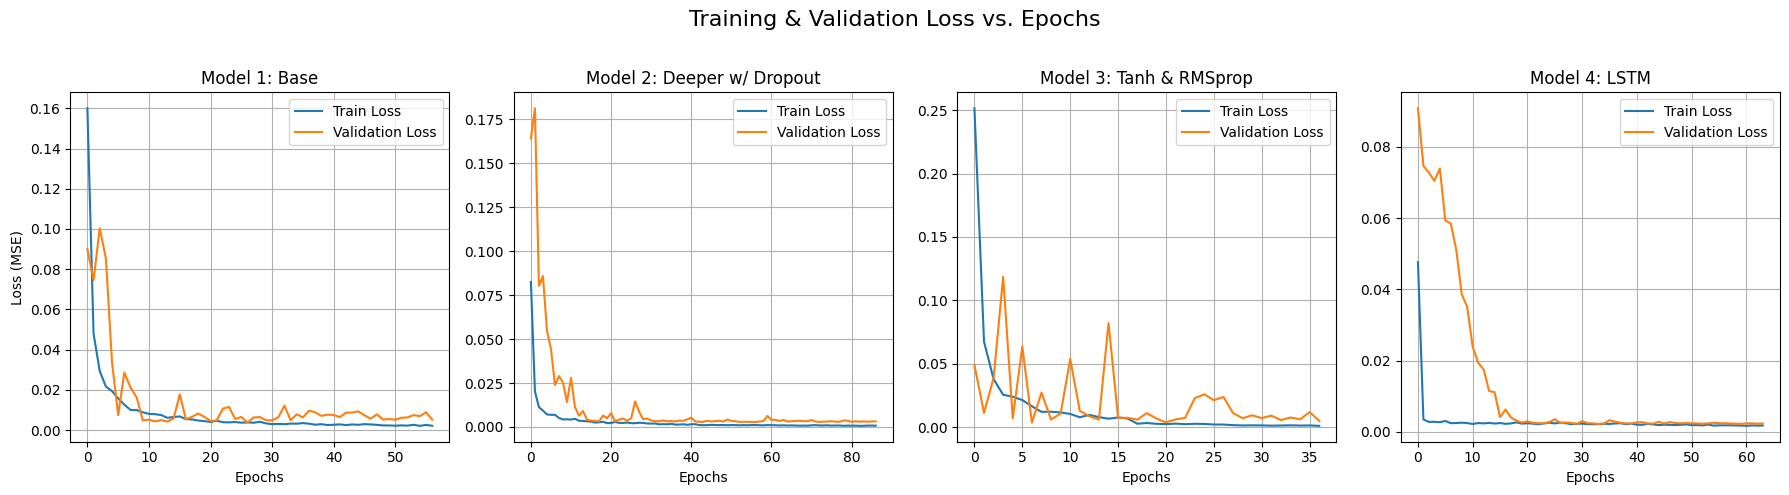

--- Best Performing Model: Weighted_Ensemble ---



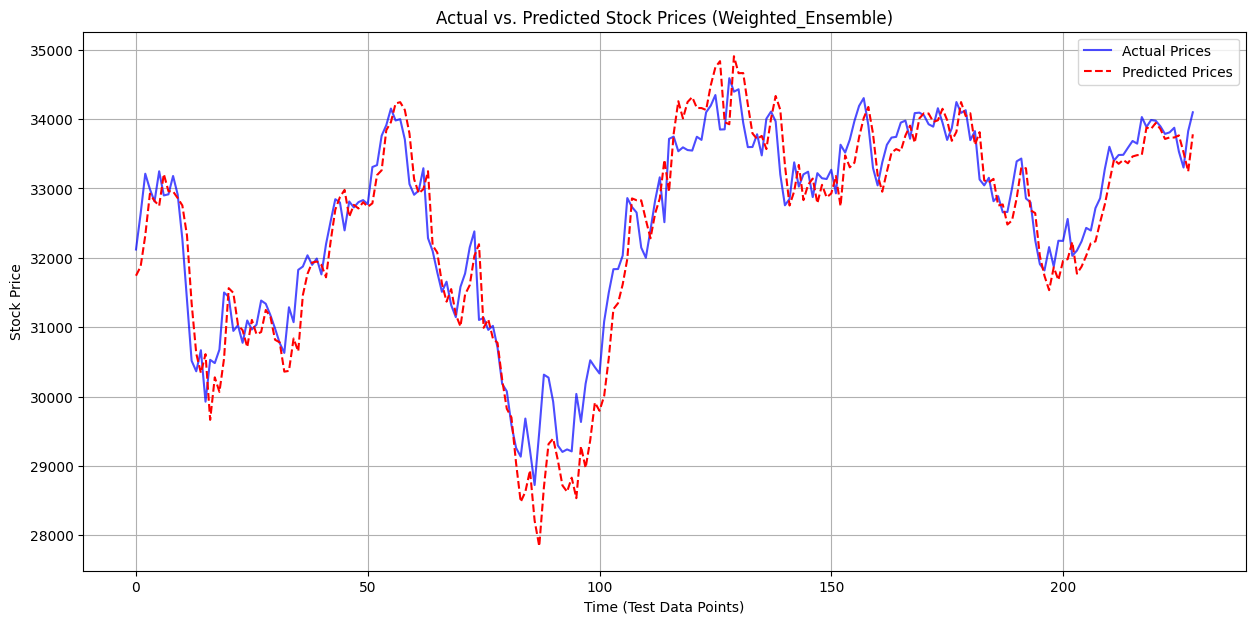

In [9]:

plt.figure(figsize=(18, 5))
plt.suptitle("Training & Validation Loss vs. Epochs", fontsize=16)

histories = [history_1, history_2, history_3, history_4]
titles = ['Model 1: Base', 'Model 2: Deeper w/ Dropout', 'Model 3: Tanh & RMSprop', 'Model 4: LSTM']

for i, (history, title) in enumerate(zip(histories, titles)):
    plt.subplot(1, 4, i+1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(title)
    plt.xlabel('Epochs')
    if i == 0: plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

best_model_name = results_df['R2 Score'].idxmax()
best_y_true, best_y_pred = predictions[best_model_name]

print(f"--- Best Performing Model: {best_model_name} ---\n")

plt.figure(figsize=(15, 7))
plt.plot(best_y_true, label='Actual Prices', color='blue', alpha=0.7)
plt.plot(best_y_pred, label='Predicted Prices', color='red', linestyle='--')
plt.title(f'Actual vs. Predicted Stock Prices ({best_model_name})')
plt.xlabel('Time (Test Data Points)')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)
plt.show()


## 9. Hyperparameter Tuning (Keras Tuner)

Before evaluating and ensembling models, we use Keras Tuner to find the best hyperparameters for the LSTM model. This process will search for the optimal number of units, learning rate, and other parameters to maximize model performance.

**Steps:**
1. Define a model-building function with tunable hyperparameters
2. Set up the Keras Tuner (RandomSearch or Hyperband)
3. Run the tuner to find the best hyperparameters
4. Train the LSTM model with the best hyperparameters

> **Note:** Hyperparameter tuning can take several minutes depending on the search space and dataset size.

In [10]:
import tensorflow as tf
import keras_tuner as kt
from tensorflow.keras.layers import LSTM, Dense, BatchNormalization
from tensorflow.keras.optimizers import Adam

# Model-building function for Keras Tuner
def build_lstm_model(hp):
    model = tf.keras.Sequential()
    model.add(LSTM(
        units=hp.Int('units1', min_value=32, max_value=256, step=32),
        activation='tanh',
        return_sequences=True,
        input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])
    ))
    model.add(BatchNormalization())
    model.add(LSTM(
        units=hp.Int('units2', min_value=16, max_value=128, step=16),
        activation='tanh',
        return_sequences=False
    ))
    model.add(Dense(
        units=hp.Int('dense_units', min_value=8, max_value=64, step=8),
        activation='relu'
    ))
    model.add(Dense(1))
    model.compile(
        optimizer=Adam(learning_rate=hp.Choice('learning_rate', [1e-2, 1e-3, 5e-4, 1e-4])),
        loss='mse',
        metrics=['mae']
    )
    return model

# Set up the tuner
lstm_tuner = kt.RandomSearch(
    build_lstm_model,
    objective='val_loss',
    max_trials=10,
    executions_per_trial=1,
    directory='lstm_tuner_dir',
    project_name='lstm_tuning'
)

# Run the tuner
lstm_tuner.search(
    X_train_lstm, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.15,
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
    verbose=2
)

# Get the best model
best_lstm_hp = lstm_tuner.get_best_hyperparameters(1)[0]
best_lstm_model = lstm_tuner.hypermodel.build(best_lstm_hp)

# Train the best model on the full training data
history_best_lstm = best_lstm_model.fit(
    X_train_lstm, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    callbacks=[early_stopping_callback, reduce_lr],
    verbose=1
)

print("Best LSTM Hyperparameters:")
for key in best_lstm_hp.values.keys():
    print(f"{key}: {best_lstm_hp.get(key)}")

Reloading Tuner from lstm_tuner_dir\lstm_tuning\tuner0.json
Epoch 1/300
25/25 [==============================] - 3s 28ms/step - loss: 0.0318 - mae: 0.0975 - val_loss: 0.0080 - val_mae: 0.0776
Epoch 2/300
25/25 [==============================] - 0s 13ms/step - loss: 0.0028 - mae: 0.0352 - val_loss: 0.0049 - val_mae: 0.0577
Epoch 3/300
25/25 [==============================] - 0s 14ms/step - loss: 0.0024 - mae: 0.0313 - val_loss: 0.0038 - val_mae: 0.0494
Epoch 4/300
25/25 [==============================] - 0s 14ms/step - loss: 0.0027 - mae: 0.0330 - val_loss: 0.0025 - val_mae: 0.0379
Epoch 5/300
25/25 [==============================] - 0s 14ms/step - loss: 0.0023 - mae: 0.0300 - val_loss: 0.0026 - val_mae: 0.0388
Epoch 6/300
25/25 [==============================] - 0s 13ms/step - loss: 0.0025 - mae: 0.0321 - val_loss: 0.0051 - val_mae: 0.0586
Epoch 7/300
25/25 [==============================] - 0s 13ms/step - loss: 0.0027 - mae: 0.0347 - val_loss: 0.0033 - val_mae: 0.0454
Epoch 8/300
25/2

## 10. Compare Manual Tuning vs Hyperparameter Tuning

This section visualizes and compares the performance of the manually tuned LSTM model and the best LSTM model found by Keras Tuner (hyperparameter tuning).

The bar chart below shows key metrics (Accuracy, R², MAPE, MAE) for both models side by side.

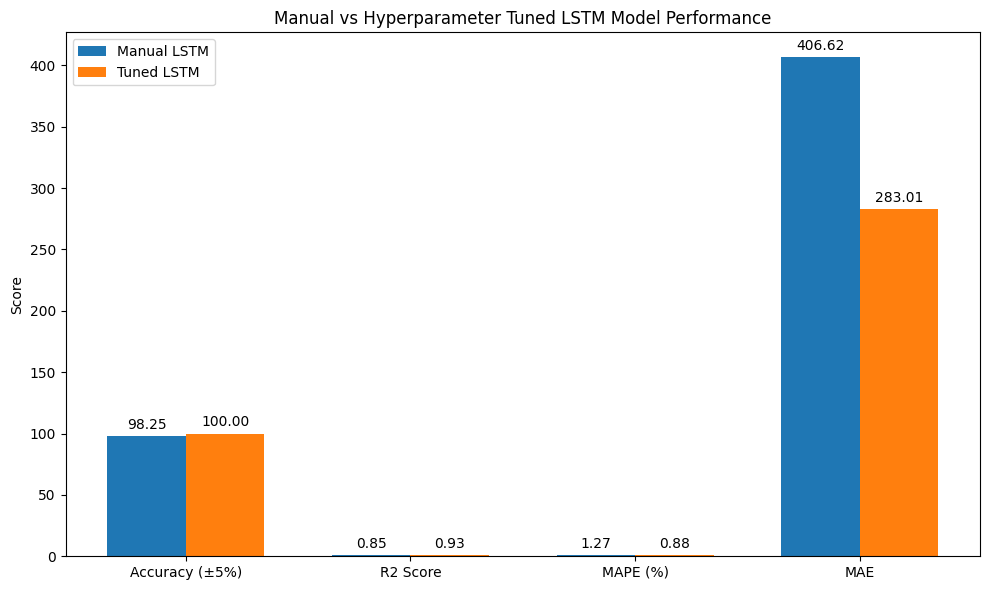

In [11]:
# Evaluate best LSTM from hyperparameter tuning
metrics_lstm_manual, y_true_manual, y_pred_manual = evaluate_model(model_4, X_test_lstm, y_test, scaler_target, close_test)
metrics_lstm_tuned, y_true_tuned, y_pred_tuned = evaluate_model(best_lstm_model, X_test_lstm, y_test, scaler_target, close_test)

labels = ['Accuracy (±5%)', 'R2 Score', 'MAPE (%)', 'MAE']
manual_scores = [metrics_lstm_manual['Accuracy (±5.0%)'], metrics_lstm_manual['R2 Score'], metrics_lstm_manual['MAPE (%)'], metrics_lstm_manual['MAE']]
tuned_scores = [metrics_lstm_tuned['Accuracy (±5.0%)'], metrics_lstm_tuned['R2 Score'], metrics_lstm_tuned['MAPE (%)'], metrics_lstm_tuned['MAE']]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, manual_scores, width, label='Manual LSTM', color='#1f77b4')
rects2 = ax.bar(x + width/2, tuned_scores, width, label='Tuned LSTM', color='#ff7f0e')

ax.set_ylabel('Score')
ax.set_title('Manual vs Hyperparameter Tuned LSTM Model Performance')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Annotate bars
for rect in rects1 + rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()
